<h1>Comprehensive Analysis of Cyber Crimes in India - Satark Model</h1>
<hr>


<h4>Problem Statement:-</h4>

Recently with integration of advanced AI Systems like LLMs, transformative technologies in communication like: WhatsApp, FaceBook, Instagram etc. there has been a sudden increase in the crimes associated with all of these new technologies called, cybercrime.

<br>

<b>Creating a Multiple Input based Linear Regression based model which can predict and analyse users risk and exposure to cyberfraud thus functioning like a, 'Risk - Analyst System.'<br></b>
<br>


<b>Cybercrime</b> in India is not evenly distributed it varies sharply across districts, years, and types. Using only the district-wise cyber crime records provided in this dataset, build a multiple linear regression model to estimate the total cyber offences for a district-year observation from its administrative identifiers and offence-category breakdown. The goal is to identify how strongly different offence categories, time trends, and regional patterns contribute to the overall cybercrime burden, so that districts with rising risk can be flagged early for targeted cyber-policing, awareness drives, and resource allocation.

<br>
<hr>

Objectives:
1. Creating a Multiple Linear Regression Model for Risk Prediction.
2. Preprocessing the data for this model.
3. Removing Null and Duplicate Values
4. Removing Outlier Values
5. Feature Selection and Engineering
6. Data Visualisations
7. Data Scaling
8. Model Training
9. Model Testing
10. Model Prediction

<h4>Dataset Description</h4>

Dataset Acquisition:

The data which I have used is acquired from an open source data website called the [Indian Data Portal - Cybercrime Dataset](https://indiadataportal.com/p/crime-statistics/r/ncrb-cii_cyber_crimes-dt-yr-aaa). Such open source websites allows students to learn more about DPEDA and provide a robust selection of data.
<hr><br>

<h4>Dataset Description:

The dataset used is a spatiotemporal compilation of various crimes in India from the year 2017 to 2022. This dataset comprises of several important columns like:


1. Violation of Privacy
2. Cyber Terrorism
3. Identity Theft
4. Data Theft
5. Banking Fraud
6. Cheating
7. Forgery etc.

These datasets along with a comprehensive categorical description of states give us a robust understanding of what is going on each state during a given year. The meta details of the data are as followed; number of rows = 5323, number of columns = 38.

<hr>



<h3>Power Bi Visuals:</h3>

After using Python Visuals and Plotting I used Power Bi to get adequate idea and analyse trends in dataset by taking advantage of dynamic graphs. I have used clean dataset in PowerBi to get a robust understanding.

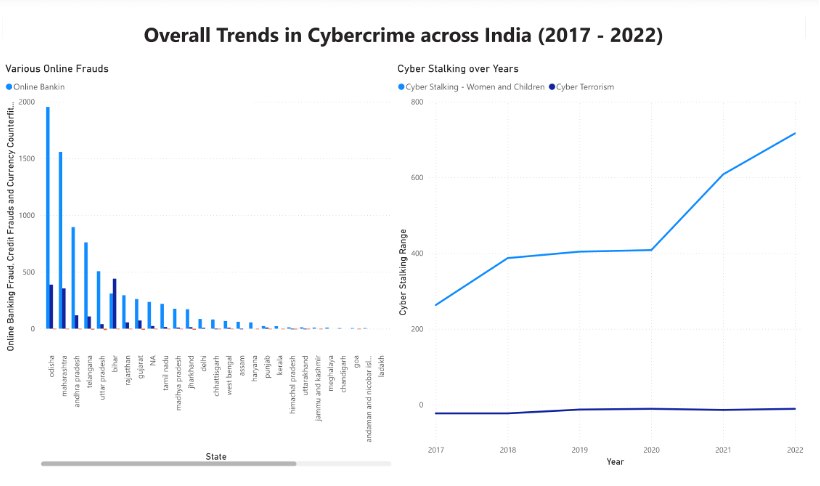

Spatiotemporal Features in the dataset.

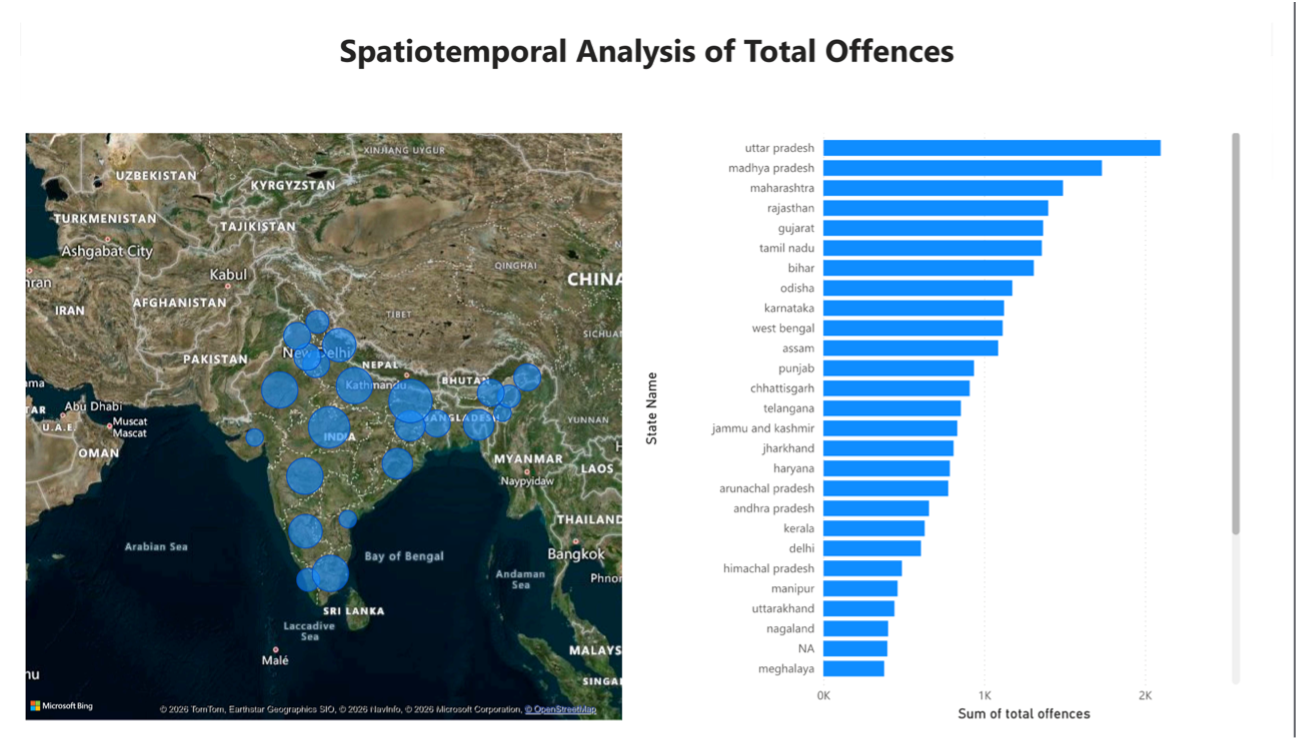

<h3>Approach: Project Pipeline</h3>
<hr>

The plan of action and complete Pipeline for Cybersecurity and Cybercrime project is as followed,

1. Loading Data in Pandas-DataFrame
2. Checking for null, duplicate values, dropping columns (if necessary)
3. Performing Imputation (KNN, Simple, bfill, ffill)
4. Checking for Outliers (Z-Score, IQR)
5. Data Visualisations using matplotlib, seaborn library
6. Data Scaling Operations
7. Data Splitting
8. Model Training
9. Model Evaluation
10. Model Testing
<hr>

Task 1: Loading Data in DataFrame

<hr>


In [ ]:
#Task 1: Importing Dependencies and Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel('/content/cybercrime_dataset_17-22.xlsx')
df.head()

,id,year,state_nm,state_code,district_name,district_cd,reg_circle,tampering_computer_source_documents,ransom_ware,offences_other_than_ransom_ware,...,cheating,forgery,defamation_morphing,fake_profile,currency_counterfeiting,stamps_counterfeiting,cyber_blackmailing_threatening,fake_news_on_social_media,other_offences,total_offences_ip
0,0,2017,Jammu And Kashmir,1,ANANTNAG,1,Anantnag,0,NaN,0,...,0,NaN,0,0,NaN,0,0,0,0,0
1,1,2017,Jammu And Kashmir,1,pulwama,11,Awantipora,0,0,NaN,...,0,0,0,0,0,0,0,0,0,0
2,2,2017,jammu and kashmir,1,Bandipora,623,Bandipora,0,0,NaN,...,0,0,0,0,0,0,0,0,0,0
3,3,2017,Jammu And Kashmir,1,Baramulla,3,Baramulla,0,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
4,4,2017,Jammu And Kashmir,1,Budgam,2,Budgam,0,0,0,...,0,NaN,0,NaN,0,NaN,0,0,0,0


In [ ]:
df.shape

(5322, 38)

In [ ]:
#Getting info of columns

df.columns

Index(['id', 'year', 'state_nm', 'state_code', 'district_name', 'district_cd',
       'reg_circle', 'tampering_computer_source_documents', 'ransom_ware',
       'offences_other_than_ransom_ware',
       'dishonestly_recv_stolen_cmp_resrc_or_comm_device', 'identity_theft',
       'cheating_by_personation_by_using_computer_resource',
       'violation_of_privacy', 'cyber_terrorism', 'other_sections_it_act',
       'interception_or_monitoring_or_decryption_of_info',
       'un_athryz_access_atmpt_access_prct_comp_sys',
       'abetment_to_commit_offences', 'attempt_to_commit_offences',
       'other_sections_of_it_act', 'cyber_stalking_bullying_of_women_children',
       'data_theft', 'credit_card_debit_card_fraud', 'atms_fraud',
       'online_banking_fraud', 'otp_frauds', 'other_frauds', 'cheating',
       'forgery', 'defamation_morphing', 'fake_profile',
       'currency_counterfeiting', 'stamps_counterfeiting',
       'cyber_blackmailing_threatening', 'fake_news_on_social_media',
    

In [ ]:
#Dropping redundant and unnecessary columns - Increasing model efficiency and generalising scope

df = df.drop(columns=['district_name','reg_circle', 'interception_or_monitoring_or_decryption_of_info',
                 'un_athryz_access_atmpt_access_prct_comp_sys','defamation_morphing', 'stamps_counterfeiting',
                 'fake_news_on_social_media','total_offences_ip', 'other_offences', 'fake_profile',
                 'data_theft', 'attempt_to_commit_offences', 'abetment_to_commit_offences',
                 'other_sections_it_act', 'cheating_by_personation_by_using_computer_resource', 'dishonestly_recv_stolen_cmp_resrc_or_comm_device',
                 'tampering_computer_source_documents', 'otp_frauds', 'other_frauds', 'forgery', 'id', 'state_code'])

<hr>

Task 2: Null Value Summation and Duplicate Value Checking

<hr>

In [ ]:
#Getting value counts of each of the column

df.isnull().sum()

,0
year,13
state_nm,27
district_cd,501
ransom_ware,498
offences_other_than_ransom_ware,498
identity_theft,503
violation_of_privacy,501
cyber_terrorism,505
other_sections_of_it_act,499
cyber_stalking_bullying_of_women_children,510


In [ ]:
df.head()

,year,state_nm,district_cd,ransom_ware,offences_other_than_ransom_ware,identity_theft,violation_of_privacy,cyber_terrorism,other_sections_of_it_act,cyber_stalking_bullying_of_women_children,credit_card_debit_card_fraud,atms_fraud,online_banking_fraud,cheating,currency_counterfeiting,cyber_blackmailing_threatening
0,2017,Jammu And Kashmir,1,NaN,0,0,0,0,0,0,0,NaN,0,0,NaN,0
1,2017,Jammu And Kashmir,11,0,NaN,0,0,0,0,0,0,0,0,0,0,0
2,2017,jammu and kashmir,623,0,NaN,unknown,NaN,0,-2,0,0,NaN,0,0,0,0
3,2017,Jammu And Kashmir,3,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0
4,2017,Jammu And Kashmir,2,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.duplicated().sum()

np.int64(32)

<hr>

1. Year - Performing bfill and ffill as the values will be in range
2. State Name - Performing bfill and ffill as the values will be in related ranges
3. Other Columns - Simple Imputation

Performing KNN Imputation would result in solving simple problem with complex problem

<hr>

Task 3: Imputation Operations and Filling Data

<hr>

In [ ]:
#Using ffill() to impute missing values


df['year'] = df['year'].ffill()
df['year'].isnull().sum()

np.int64(0)

In [ ]:
#Using bfill, ffill to impute missing 'State' Values

df['state_nm'] = df['state_nm'].bfill()
df['state_nm'] = df['state_nm'].ffill()
df['state_nm'].isnull().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5322 entries, 0 to 5321
Data columns (total 16 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   year                                       5322 non-null   object
 1   state_nm                                   5322 non-null   object
 2   district_cd                                4821 non-null   object
 3   ransom_ware                                4824 non-null   object
 4   offences_other_than_ransom_ware            4824 non-null   object
 5   identity_theft                             4819 non-null   object
 6   violation_of_privacy                       4821 non-null   object
 7   cyber_terrorism                            4817 non-null   object
 8   other_sections_of_it_act                   4823 non-null   object
 9   cyber_stalking_bullying_of_women_children  4812 non-null   object
 10  credit_card_debit_card_fraud        

In [ ]:
df.columns

Index(['year', 'state_nm', 'district_cd', 'ransom_ware',
       'offences_other_than_ransom_ware', 'identity_theft',
       'violation_of_privacy', 'cyber_terrorism', 'other_sections_of_it_act',
       'cyber_stalking_bullying_of_women_children',
       'credit_card_debit_card_fraud', 'atms_fraud', 'online_banking_fraud',
       'cheating', 'currency_counterfeiting',
       'cyber_blackmailing_threatening'],
      dtype='object')

In [ ]:
cols = ['year', 'ransom_ware',
       'offences_other_than_ransom_ware', 'identity_theft',
       'violation_of_privacy', 'cyber_terrorism', 'other_sections_of_it_act',
       'cyber_stalking_bullying_of_women_children',
       'credit_card_debit_card_fraud', 'atms_fraud', 'online_banking_fraud',
       'cheating', 'currency_counterfeiting',
       'cyber_blackmailing_threatening']

In [ ]:
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5322 entries, 0 to 5321
Data columns (total 16 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   year                                       5308 non-null   float64
 1   state_nm                                   5322 non-null   object 
 2   district_cd                                4821 non-null   object 
 3   ransom_ware                                4781 non-null   float64
 4   offences_other_than_ransom_ware            4780 non-null   float64
 5   identity_theft                             4781 non-null   float64
 6   violation_of_privacy                       4790 non-null   float64
 7   cyber_terrorism                            4788 non-null   float64
 8   other_sections_of_it_act                   4794 non-null   float64
 9   cyber_stalking_bullying_of_women_children  4792 non-null   float64
 10  credit_card_debit_card_f

In [ ]:
#Importing Dependencies for
from sklearn.impute import KNNImputer, SimpleImputer

In [ ]:
imputer = SimpleImputer(strategy='most_frequent')
df[cols] = imputer.fit_transform(df[cols])

In [ ]:
knn_imputer = KNNImputer(n_neighbors=3)
df['district_cd'] = df['district_cd'].replace({'TBD': 0, '':0, 'unknown': 0, 'x':0, 'missing':0, '--':0})
df[['district_cd']] = knn_imputer.fit_transform(df[['district_cd']])

/tmp/ipykernel_966/3143019124.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['district_cd'] = df['district_cd'].replace({'TBD': 0, '':0, 'unknown': 0, 'x':0, 'missing':0, '--':0})


In [ ]:
df.isnull().sum()

,0
year,0
state_nm,0
district_cd,0
ransom_ware,0
offences_other_than_ransom_ware,0
identity_theft,0
violation_of_privacy,0
cyber_terrorism,0
other_sections_of_it_act,0
cyber_stalking_bullying_of_women_children,0


In [ ]:
df.duplicated().sum()

np.int64(158)

In [ ]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

<hr>

Task 4: Outlier Detection

Outliers are datapoints which deviate from standard or normal distribution. These points create statistical, accuracy based and predictive errors thus, they need to be dealt with. I have utilised IQR based method for detection and removal of outlier based on, Boxplot. Boxplot utilises 5 main parameters: min, max, median, 25th percentile and 75th percentile.

<hr>

In [ ]:
def IQR(df):
  Q1 = df.quantile(0.25)
  Q3 = df.quantile(0.75)
  IQR = Q3 - Q1

  lower_quartile = Q1 - 3 * IQR
  upper_quartile = Q3 + 3 * IQR

  mask = ((df[cols] < lower_quartile) | (df[cols] > upper_quartile)).any(axis=1)
  return mask

In [ ]:
mask_iqr = IQR(df[cols])

<hr>

The **3-sigma rule** states that in a normal distribution, nearly all data points lie within three standard deviations of the mean. Values falling beyond **±3σ** are considered statistically rare and are typically flagged as outliers. It provides a simple, probabilistic threshold for identifying extreme deviations from expected behavior. However, its reliability depends on the assumption of normality, making it less effective for skewed or count-based data distributions.

<hr>

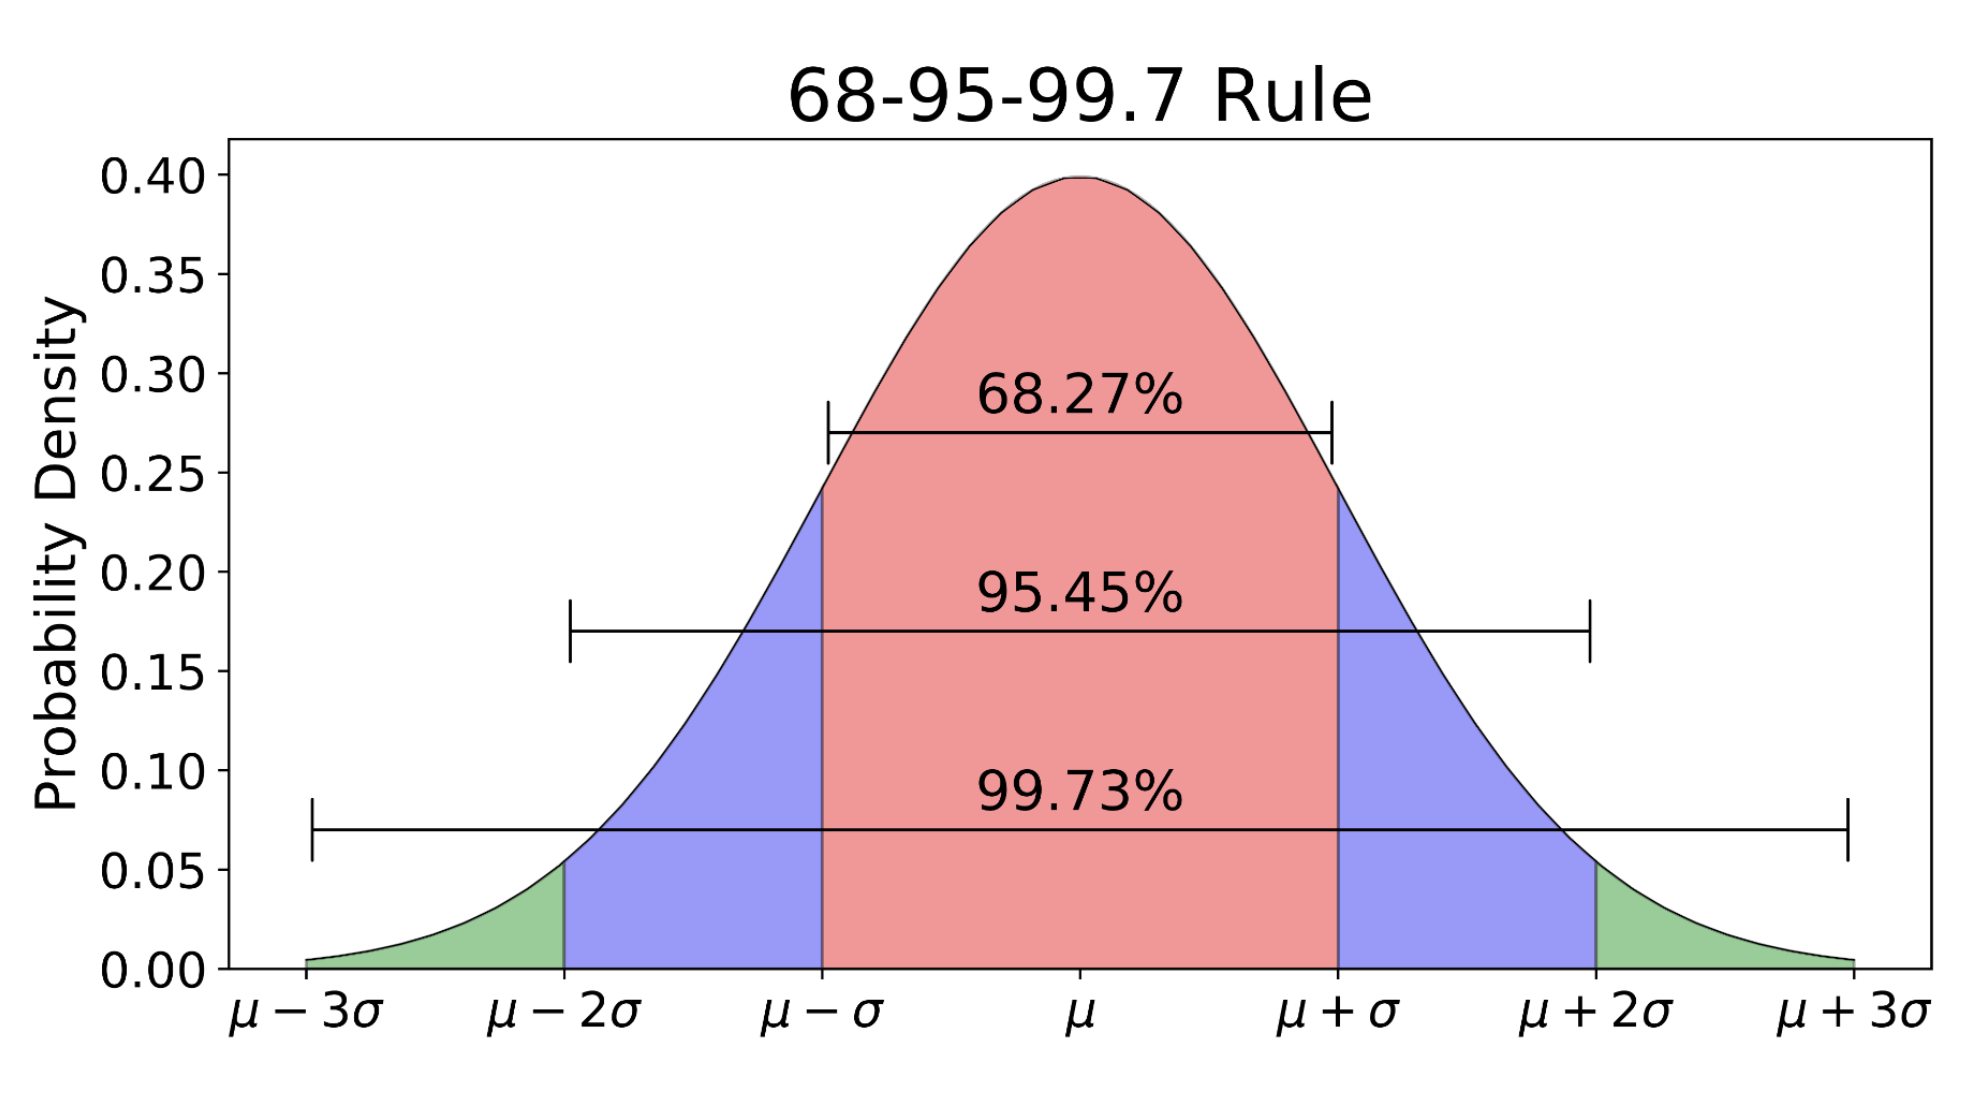

In [ ]:
def sigma3(df):
  mean = df[cols].mean()
  std = df[cols].std()
  mask = ((df[cols] - mean) / std > 3).any(axis=1)
  return mask

In [ ]:
mask_outlier = sigma3(df[cols])
mask_outlier.value_counts()

,count
False,4914
True,250


In [ ]:
df.shape

(5164, 16)

<hr>

Textual inconsistencies, such as variations in spelling, casing, and formatting, lead to redundant representations of the same entity within a dataset. This causes duplication, increases data sparsity, and distorts analysis. In machine learning, it results in incorrect feature encoding, misleading patterns, and reduced model accuracy, making data cleaning a critical preprocessing step.

<hr>

In [ ]:
df['state_nm'].unique()

array(['Jammu And Kashmir', 'jammu and kashmir', 'JAMMU AND KASHMIR',
       ' Jammu And Kashmir ', '?', 'Jaammu And Kashmir',
       'Himachal Pradesh', 'himachal pradesh', ' Himachal Pradesh ',
       'HIMACHAL PRADESH', 'Himaachal Pradesh', 'Punjab', 'PUNJAB',
       'Punjaab', 'punjab', ' Punjab ', 'Gujarat', 'Kerala',
       'Madhya Pradesh', 'Chandigarh', 'Chaandigarh', ' Chandigarh ',
       'uttarakhand', 'Uttarakhand', 'UTTARAKHAND', 'Uttaarakhand',
       ' Uttarakhand ', '‚Äî', 'Haryana', 'haryana', ' Haryana ',
       'HARYANA', 'unknown', 'Haaryana', 'Delhi', 'Maharashtra', 'DELHI',
       'delhi', ' Delhi ', 'Rajasthan', ' Rajasthan ', 'BIHAR',
       'RAJASTHAN', 'rajasthan', 'Meghalaya', 'Uttar Pradesh',
       'UTTAR PRADESH', 'uttar pradesh', ' Uttar Pradesh ',
       'Uttaar Pradesh', 'Assam', 'Bihar', ' Bihar ', 'Bihaar', 'bihar',
       'Odisha', 'Sikkim', 'SIKKIM', 'sikkim', 'Arunachal Pradesh',
       'ARUNACHAL PRADESH', ' Arunachal Pradesh ', 'arunachal pradesh

In [ ]:
df['state_nm'] = df['state_nm'].str.lower()
df['state_nm'] = df['state_nm'].str.strip() #Removing Spaces
df['state_nm'] = df['state_nm'].replace({'the': '', 'and': ''})
df['state_nm'].unique()

array(['jammu and kashmir', '?', 'jaammu and kashmir', 'himachal pradesh',
       'himaachal pradesh', 'punjab', 'punjaab', 'gujarat', 'kerala',
       'madhya pradesh', 'chandigarh', 'chaandigarh', 'uttarakhand',
       'uttaarakhand', '‚äî', 'haryana', 'unknown', 'haaryana', 'delhi',
       'maharashtra', 'rajasthan', 'bihar', 'meghalaya', 'uttar pradesh',
       'uttaar pradesh', 'assam', 'bihaar', 'odisha', 'sikkim',
       'arunachal pradesh', 'arunaachal pradesh', 'nagaland', 'naagaland',
       'manipur', 'maanipur', 'mizoram', 'mizoraam', 'tripura', 'assaam',
       'chhattisgarh', 'west bengal', 'west bengaal', 'jharkhand',
       'jhaarkhand', 'odishaa', 'chhaattisgarh', 'maadhya pradesh',
       'gujaarat', 'maaharashtra', 'telangana', 'andhra pradesh',
       'karnataka', 'kaarnataka', 'goa', 'lakshadweep', 'keraala',
       'tamil nadu', 'taamil nadu', 'puducherry',
       'andaman and nicobar islands', 'telaangana', 'ladakh', 'laadakh',
       'the dadra and nagar haveli 

In [ ]:
state_mapping = {
    'jammu and kashmir': 'jammu and kashmir',
    'jaammu and kashmir': 'jammu and kashmir',
    'himachal pradesh': 'himachal pradesh',
    'himaachal pradesh': 'himachal pradesh',
    'punjaab': 'punjab',
    'uttarakhand': 'uttarakhand',
    'uttaarakhand': 'uttarakhand',
    'haaryana': 'haryana',
    'chaandigarh': 'chandigarh',
    'bihaar': 'bihar',
    'assam': 'assam',
    'assaam': 'assam',
    'odishaa': 'odisha',
    'jhaarkhand': 'jharkhand',
    'chhaattisgarh': 'chhattisgarh',
    'maadhya pradesh': 'madhya pradesh',
    'gujaarat': 'gujarat',
    'maharashtra': 'maharashtra',
    'maaharashtra': 'maharashtra',
    'kaarnataka': 'karnataka',
    'keraala': 'kerala',
    'taamil nadu': 'tamil nadu',
    'telaangana': 'telangana',
    'west bengaal':'west bengal',
    'laadakh': 'ladakh',
    'uttaar pradesh':'uttar pradesh',
    'mizoraam': 'mizoram',
    'maanipur': 'manipur',
    'naagaland': 'nagaland',
    'arunaachal pradesh': 'arunachal pradesh',
}

df['state_nm'] = df['state_nm'].replace(state_mapping)
df['state_nm'].unique()

array(['jammu and kashmir', '?', 'himachal pradesh', 'punjab', 'gujarat',
       'kerala', 'madhya pradesh', 'chandigarh', 'uttarakhand', '‚äî',
       'haryana', 'unknown', 'delhi', 'maharashtra', 'rajasthan', 'bihar',
       'meghalaya', 'uttar pradesh', 'assam', 'odisha', 'sikkim',
       'arunachal pradesh', 'nagaland', 'manipur', 'mizoram', 'tripura',
       'chhattisgarh', 'west bengal', 'jharkhand', 'telangana',
       'andhra pradesh', 'karnataka', 'goa', 'lakshadweep', 'tamil nadu',
       'puducherry', 'andaman and nicobar islands', 'ladakh',
       'the dadra and nagar haveli and daman and diu'], dtype=object)

In [ ]:
df['state_nm'] = df['state_nm'].replace({'?':'NA', '‚äî': 'NA', 'unknown':'NA'})
df['state_nm'].nunique()

#Removal of Textual Inconsistencies

37

In [ ]:
df_clean = df[~mask_outlier]

In [ ]:
df_clean = df_clean.copy()

In [ ]:
df_clean.columns

Index(['year', 'state_nm', 'district_cd', 'ransom_ware',
       'offences_other_than_ransom_ware', 'identity_theft',
       'violation_of_privacy', 'cyber_terrorism', 'other_sections_of_it_act',
       'cyber_stalking_bullying_of_women_children',
       'credit_card_debit_card_fraud', 'atms_fraud', 'online_banking_fraud',
       'cheating', 'currency_counterfeiting',
       'cyber_blackmailing_threatening'],
      dtype='object')

In [ ]:
crime_cols = ['ransom_ware',
       'offences_other_than_ransom_ware', 'identity_theft',
       'violation_of_privacy', 'cyber_terrorism', 'other_sections_of_it_act',
       'cyber_stalking_bullying_of_women_children',
       'credit_card_debit_card_fraud', 'atms_fraud', 'online_banking_fraud',
       'cheating', 'currency_counterfeiting', 'cyber_blackmailing_threatening',
       ]

In [ ]:
df_clean['crime_cols_sum'] = df_clean[crime_cols].sum()

In [ ]:
#Special Iterable Set for Data Visualisation (ONLY)

df_clean['total_'] = df_clean[
    [
        'ransom_ware', 'offences_other_than_ransom_ware', 'identity_theft',
        'violation_of_privacy', 'cyber_terrorism', 'other_sections_of_it_act',
        'cyber_stalking_bullying_of_women_children',
        'credit_card_debit_card_fraud', 'atms_fraud', 'online_banking_fraud',
        'cheating', 'currency_counterfeiting',
        'cyber_blackmailing_threatening'
    ]
].sum(axis=1)

Thus, I safely removed the outliers without significantly affecting the data along with our textual inconsistenices and move it to a clean dataframe.

<hr>


Task 5: Label Encoding

Label encoding is a technique used to convert categorical data into numerical form by assigning a unique integer to each category. It is particularly useful when machine learning models require numeric inputs but the features themselves do not have an inherent order. In this method, each distinct category is mapped to a specific number such as 0, 1, 2, and so on, making the data easier to process computationally. While it is simple and memory-efficient, a key limitation is that it may introduce an artificial ordinal relationship between categories, which can mislead certain models. Therefore, it should be used carefully, especially when the categorical variables are purely nominal.

<hr>

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
encoder = LabelEncoder() #Creating an Instance of Label Encoder

In [ ]:
df_clean['state_id'] = encoder.fit_transform(df_clean['state_nm'])
df_clean.head()

#Displaying of Data After Complete Transformation

,year,state_nm,district_cd,ransom_ware,offences_other_than_ransom_ware,identity_theft,violation_of_privacy,cyber_terrorism,other_sections_of_it_act,cyber_stalking_bullying_of_women_children,credit_card_debit_card_fraud,atms_fraud,online_banking_fraud,cheating,currency_counterfeiting,cyber_blackmailing_threatening,crime_cols_sum,total_,state_id
0,2017.0,jammu and kashmir,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,13
1,2017.0,jammu and kashmir,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,13
2,2017.0,jammu and kashmir,623.0,0.0,0.0,0.0,0.0,0.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,-2.0,13
3,2017.0,jammu and kashmir,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,13
4,2017.0,jammu and kashmir,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,13


<hr>

Task 6: Data Visualisation

Data visualization in Python helps turn raw data into something you can actually understand at a glance. It makes it easier to spot patterns, trends, and outliers that numbers alone can not show clearly. Good visuals also help you check if your data makes sense before building models. They are important for explaining your findings in a simple and clear way. Overall, visualization is a key step in making better data-driven decisions.

<hr>

Figure 1: State Wise Pie Chart for Crime Distributon (Univariate)

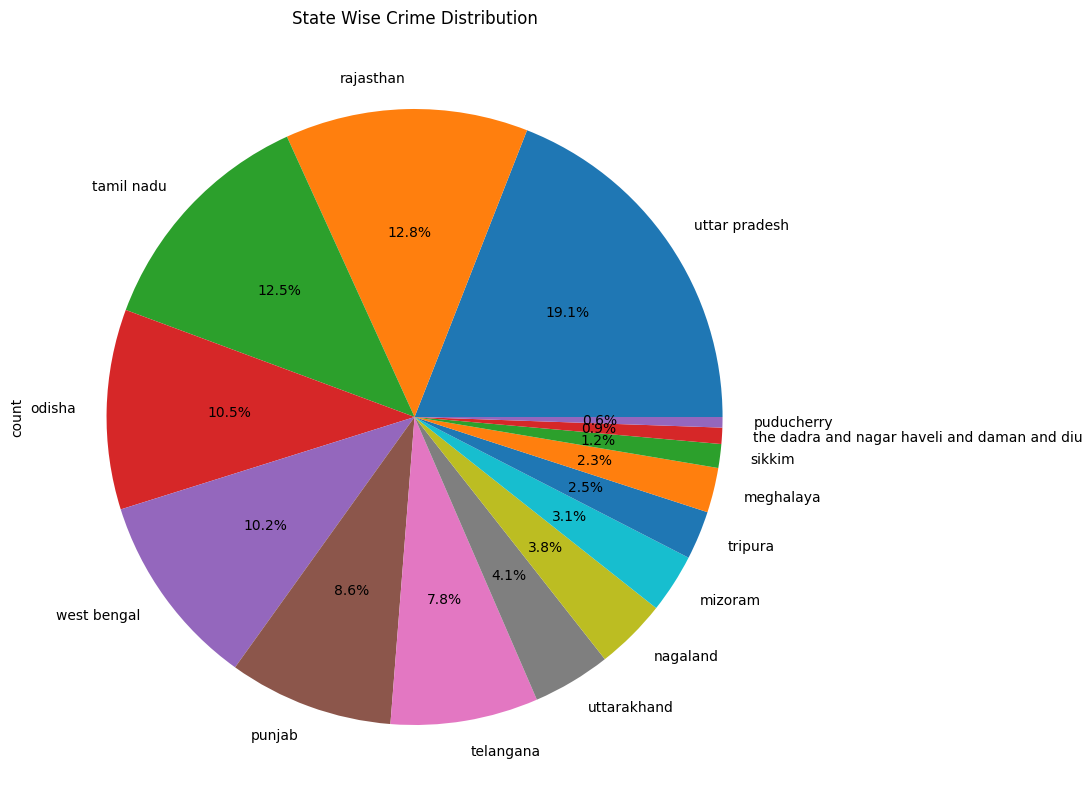

'Using the clean dataframe in descending values and taking the top 2000 rows to get an overall understanding of\nthe state with highest crime rates overall in the dataset\n\nAnalysis: Top 3 States with highest records of crime are:\n1. Uttar Pradesh\n2. Rajasthan\n3. Tamil Nadu\n'

In [ ]:
plt.figure(figsize=(10, 10))
plt.title('State Wise Crime Distribution')
df_clean['state_nm'].sort_values(ascending=False).head(2000).value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.show()


"""Using the clean dataframe in descending values and taking the top 2000 rows to get an overall understanding of
the state with highest crime rates overall in the dataset

Analysis: Top 3 States with highest records of crime are:
1. Uttar Pradesh
2. Rajasthan
3. Tamil Nadu
"""

<hr>

Figure 2. Histogram of Cyber Blackmailing (Univariate)

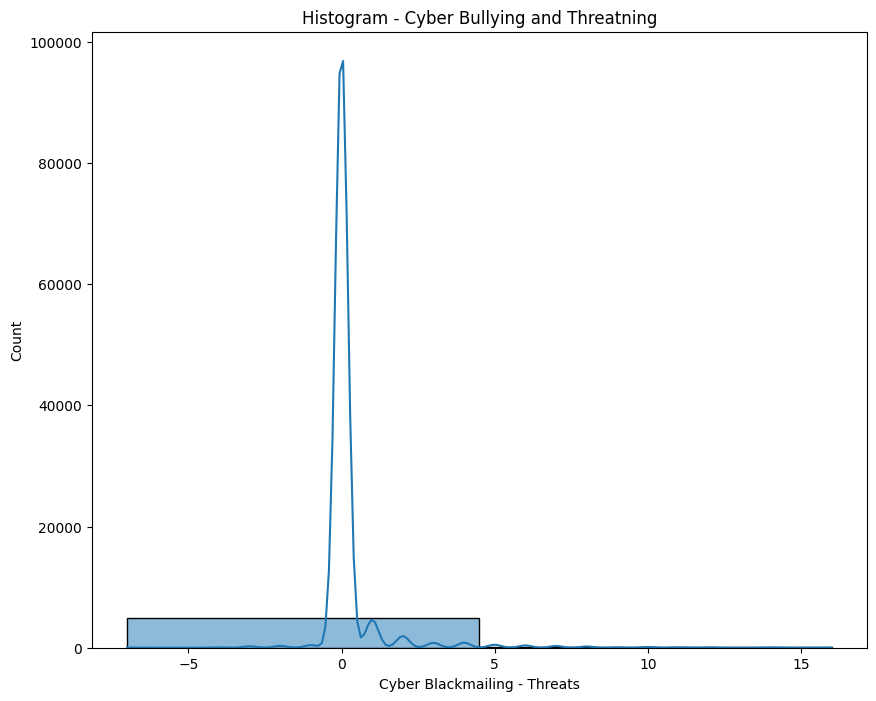

In [ ]:
plt.figure(figsize=(10, 8))
sns.histplot(df_clean['cyber_blackmailing_threatening'], bins=2, kde=True)
plt.xlabel('Cyber Blackmailing - Threats')
plt.title('Histogram - Cyber Bullying and Threatning')
plt.show()

<hr>

Figure 3. Credit Card Fraud in Each State (Bivariate)

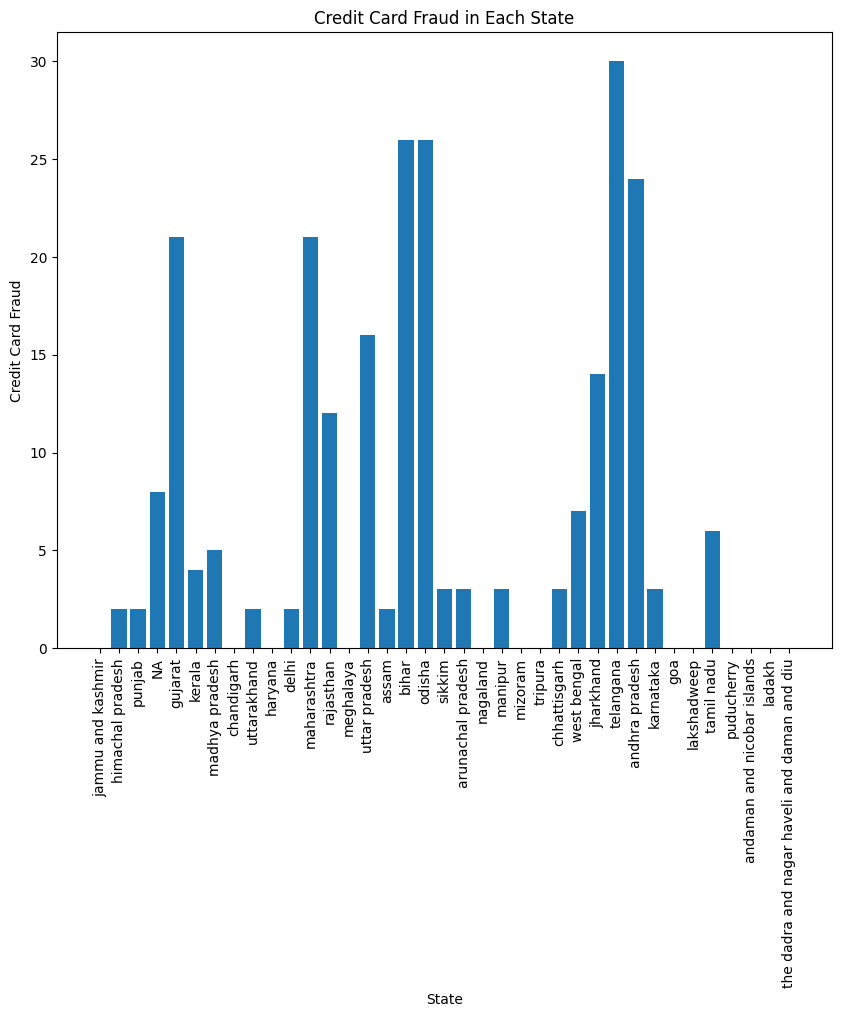

In [ ]:
plt.figure(figsize=(10,8))
plt.bar(df_clean['state_nm'], df_clean['credit_card_debit_card_fraud'].abs())
plt.xticks(rotation=90)
plt.xlabel('State')
plt.ylabel('Credit Card Fraud')
plt.title('Credit Card Fraud in Each State')
plt.show()

<hr>

Figure 4. Cyber Stalking of Women and Children in Each State (Bivariate)



/tmp/ipykernel_966/2920804514.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted(df_clean['state_nm']), y=df_clean['cyber_stalking_bullying_of_women_children'].abs(), palette='viridis')


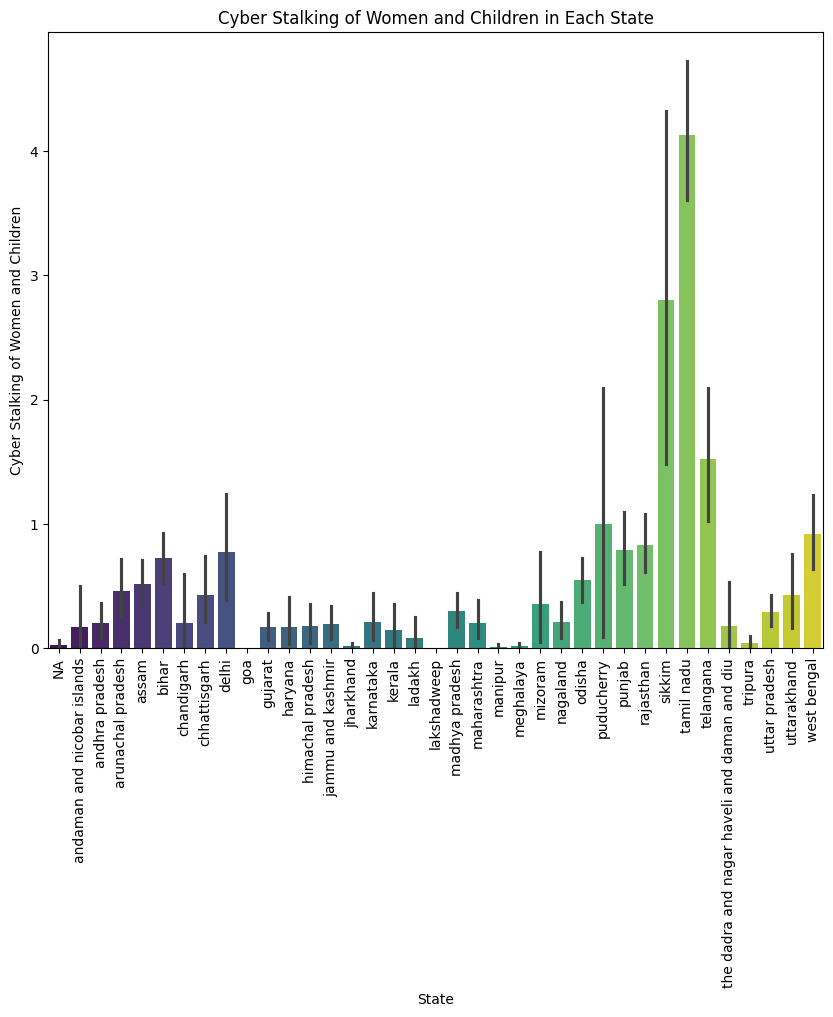

In [ ]:
plt.figure(figsize=(10,8))
sns.barplot(x=sorted(df_clean['state_nm']), y=df_clean['cyber_stalking_bullying_of_women_children'].abs(), palette='viridis')
plt.xticks(rotation=90)
plt.xlabel('State')
plt.ylabel('Cyber Stalking of Women and Children')
plt.title('Cyber Stalking of Women and Children in Each State')
plt.show()

<hr>

Figure 5. Heatmap of all the numeric columns (Multivariate)

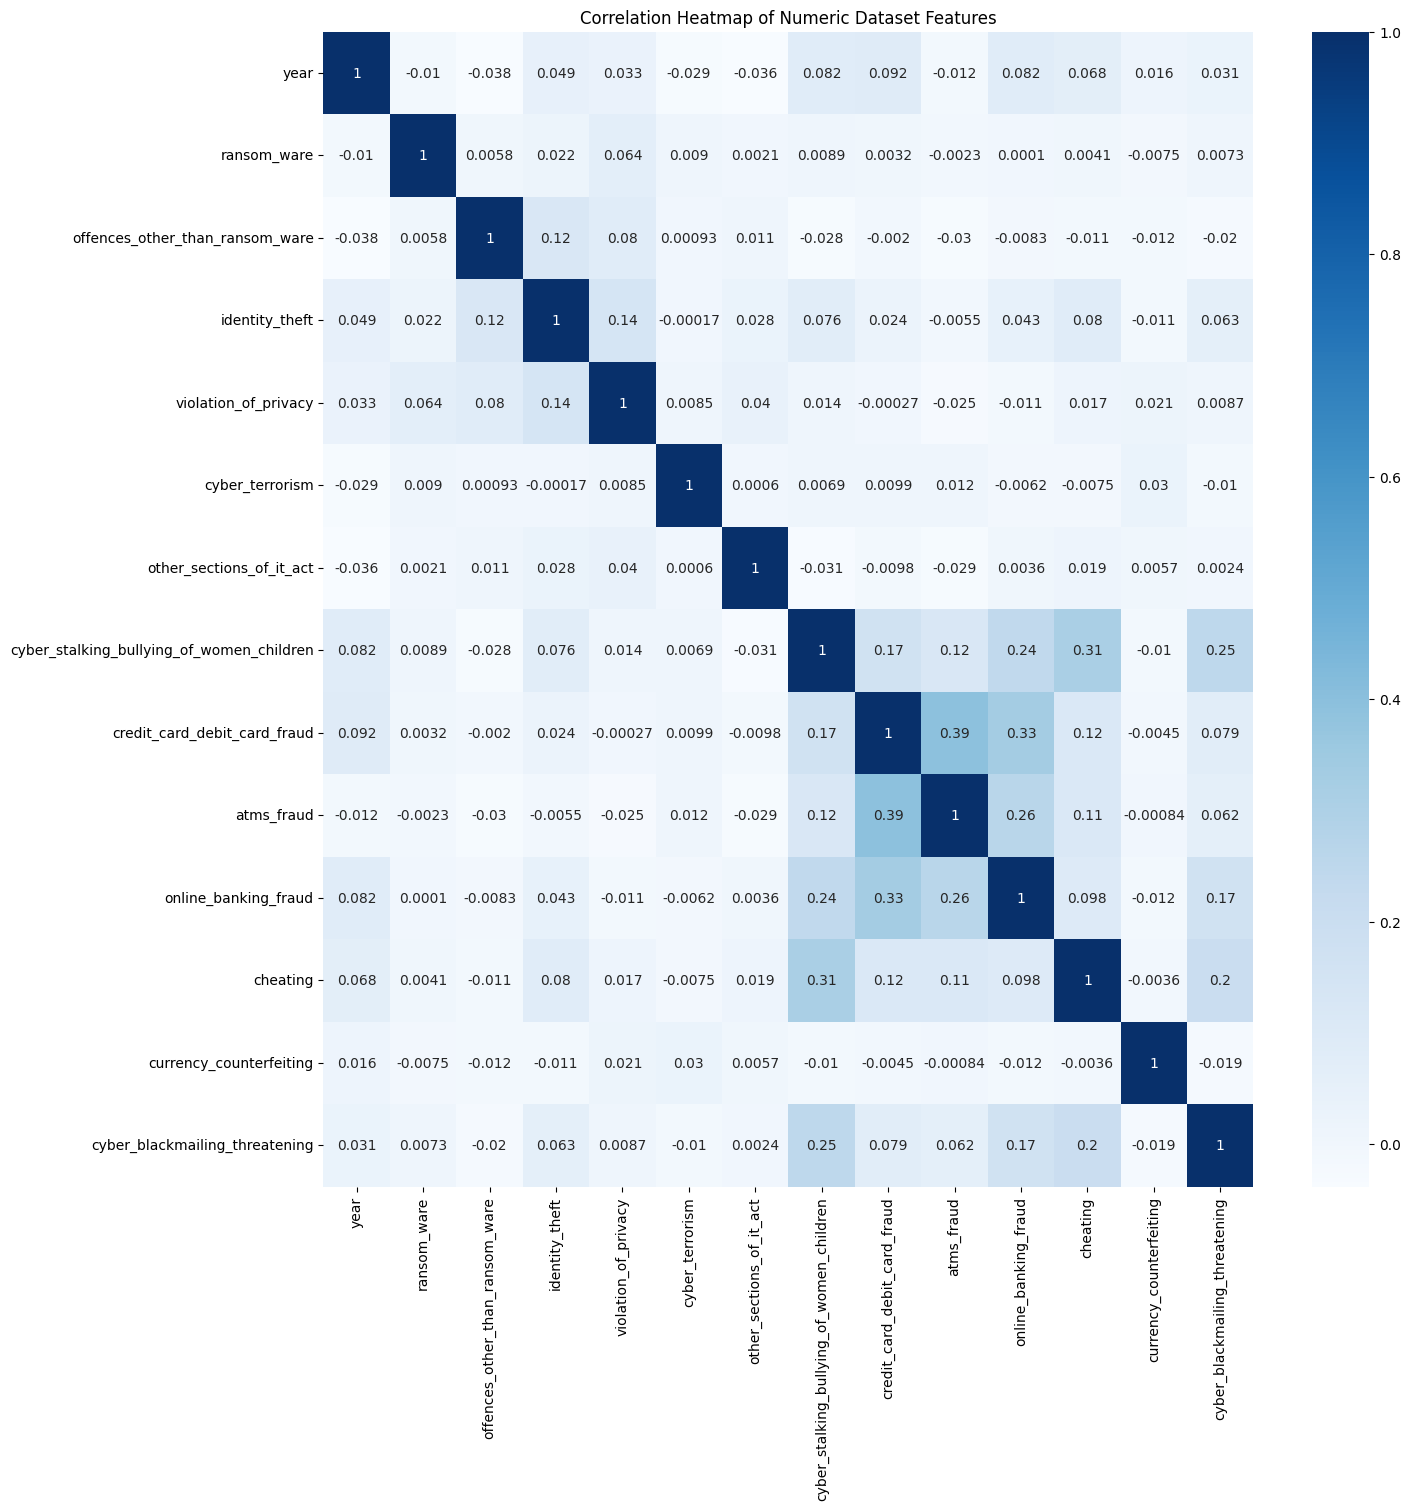

In [ ]:
plt.figure(figsize=(15, 15))
sns.heatmap(df_clean[cols].abs().corr(), annot=True, cmap='Blues')
plt.title('Correlation Heatmap of Numeric Dataset Features')
plt.show()

<hr>

Figure 6. Line Graph: Crime Evolution per Year

Describes the evolution or increase in: Credit Debit Fraud, Privacy relate offenses, and cyberterrorism

<Figure size 1000x800 with 0 Axes>

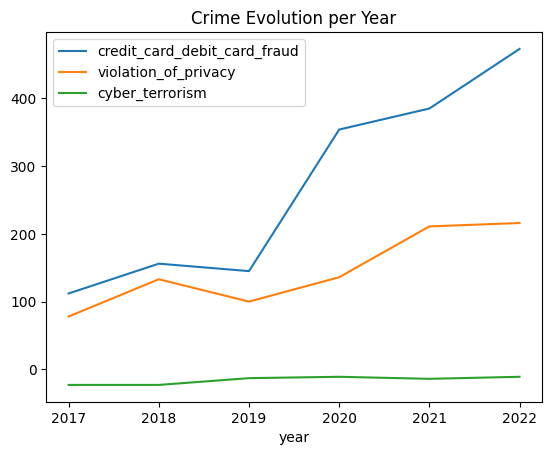

In [ ]:
plt.figure(figsize=(10,8))
df_clean.groupby('year')[['credit_card_debit_card_fraud','violation_of_privacy','cyber_terrorism' ]].sum().plot(kind='line')
plt.title('Crime Evolution per Year')
plt.show()

<hr>

Figure 7. Rise in Identity Theft Metric across India

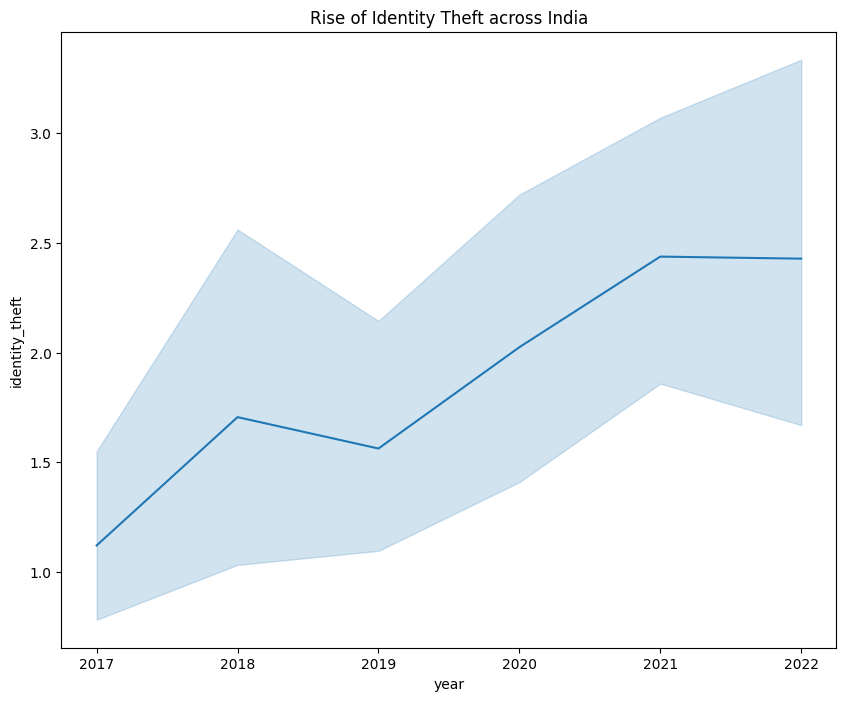

In [ ]:
plt.figure(figsize=(10,8))
sns.lineplot(data=df_clean, x='year', y='identity_theft')
plt.title("Rise of Identity Theft across India")
plt.show()

<hr>

Figure 8. KDE Plot for Crime Distribution

A KDE plot estimates the continuous probability density of a variable, revealing the underlying distribution shape without discrete bins.

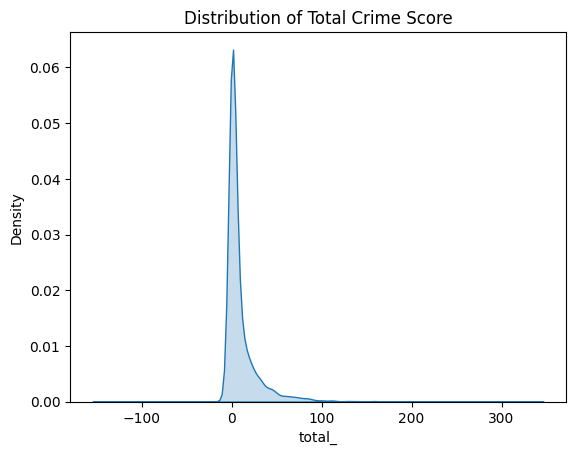

In [ ]:
sns.kdeplot(x=df_clean['total_'], fill=True)
plt.title('Distribution of Total Crime Score')
plt.show()

<hr>

Figure 9. Violin Map for Distribution of Crime Data

A violin plot combines boxplot statistics with kernel density to show both distribution spread and data density across categories.

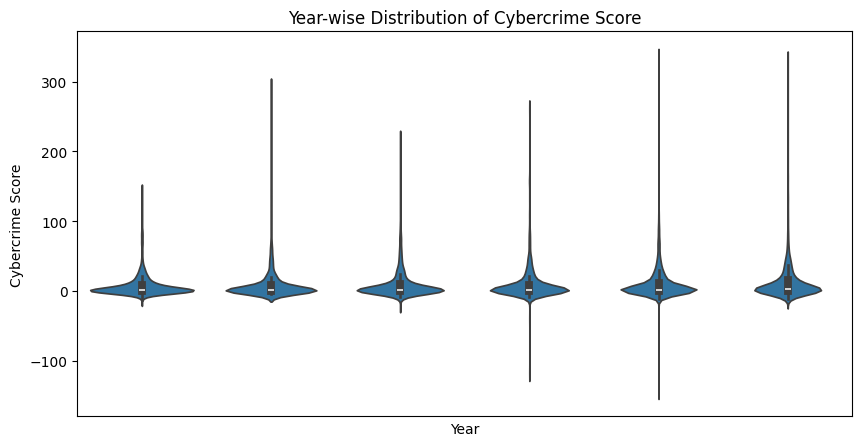

In [ ]:
plt.figure(figsize=(10,5))
sns.violinplot(data=df_clean, x='year', y='total_')
plt.title('Year-wise Distribution of Cybercrime Score')
plt.xticks([])
plt.xlabel('Year')
plt.ylabel('Cybercrime Score')
plt.show()

<hr>

Figure 10. Scatterplot

Scatterplots are less suitable because the dataset is dominated by categorical and discrete variables, causing overplotting and weak continuous relationships, making density-based visuals more informative. <h3><b>Thus, I did NOT include scatterplots in our report</b>

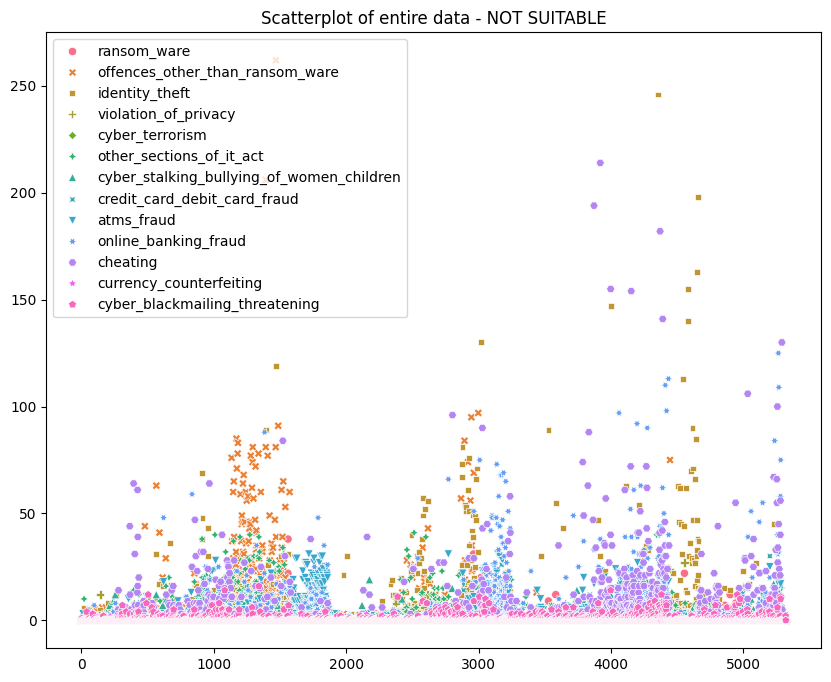

In [ ]:
cols.remove('year')
plt.figure(figsize=(10, 8))
sns.scatterplot(df_clean[cols].abs())
plt.title('Scatterplot of entire data - NOT SUITABLE')
plt.show()

<hr>

Task 7: MinMax Scaling
<br>


Min-Max scaling is a normalization technique used to transform numerical data into a fixed range, typically between 0 and 1. It works by subtracting the minimum value of a feature and dividing by the range (maximum minus minimum), ensuring that all values are proportionally scaled. This method preserves the original distribution and relationships between data points while bringing different features onto a comparable scale. It is especially useful for distance-based algorithms and models sensitive to feature magnitude. However, it is sensitive to outliers, as extreme values can significantly affect the scaling range.


In [ ]:
#Importing Dependencies
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [ ]:
df_clean[cols] = scaler.fit_transform(df_clean[cols]) #using min max scaling on the data
df_clean

,year,state_nm,district_cd,ransom_ware,offences_other_than_ransom_ware,identity_theft,violation_of_privacy,cyber_terrorism,other_sections_of_it_act,cyber_stalking_bullying_of_women_children,credit_card_debit_card_fraud,atms_fraud,online_banking_fraud,cheating,currency_counterfeiting,cyber_blackmailing_threatening,crime_cols_sum,total_,state_id
0,2017.0,jammu and kashmir,1.000000,0.061224,0.729805,0.061069,0.470588,1.0,0.327869,0.375,0.433962,0.367347,0.074074,0.170543,1.0,0.304348,NaN,0.0,13
1,2017.0,jammu and kashmir,11.000000,0.061224,0.729805,0.061069,0.470588,1.0,0.327869,0.375,0.433962,0.367347,0.074074,0.170543,1.0,0.304348,NaN,0.0,13
2,2017.0,jammu and kashmir,623.000000,0.061224,0.729805,0.061069,0.470588,1.0,0.295082,0.375,0.433962,0.367347,0.074074,0.170543,1.0,0.304348,NaN,-2.0,13
3,2017.0,jammu and kashmir,3.000000,0.061224,0.729805,0.061069,0.470588,1.0,0.327869,0.375,0.433962,0.367347,0.074074,0.170543,1.0,0.304348,NaN,0.0,13
4,2017.0,jammu and kashmir,2.000000,0.061224,0.729805,0.061069,0.470588,1.0,0.327869,0.375,0.433962,0.367347,0.074074,0.170543,1.0,0.304348,NaN,0.0,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5317,2021.0,the dadra and nagar haveli and daman and diu,463.000000,0.061224,0.729805,0.061069,0.470588,1.0,0.327869,0.375,0.433962,0.367347,0.074074,0.170543,1.0,0.304348,NaN,0.0,32
5318,2021.0,the dadra and nagar haveli and daman and diu,464.000000,0.061224,0.729805,0.061069,0.470588,1.0,0.327869,0.375,0.433962,0.367347,0.074074,0.170543,1.0,0.304348,NaN,0.0,32
5319,2022.0,the dadra and nagar haveli and daman and diu,358.659199,0.061224,0.729805,0.061069,0.470588,1.0,0.327869,0.375,0.433962,0.367347,0.074074,0.170543,1.0,0.217391,NaN,-2.0,32
5320,2022.0,the dadra and nagar haveli and daman and diu,463.000000,0.061224,0.729805,0.061069,0.470588,1.0,0.327869,0.375,0.433962,0.367347,0.074074,0.170543,1.0,0.304348,NaN,0.0,32


<hr>

Task 8: High Risk Column
<br>

For this dataset, the strongest use case is to build a multiple linear regression model that predicts the overall cybercrime burden for a district-year record. The target can be the total crime count, or a derived risk score, because the data is numerical and count-based.


In [ ]:
df_clean['total'] = df_clean[
    [
        'ransom_ware', 'offences_other_than_ransom_ware', 'identity_theft',
        'violation_of_privacy', 'cyber_terrorism', 'other_sections_of_it_act',
        'cyber_stalking_bullying_of_women_children',
        'credit_card_debit_card_fraud', 'atms_fraud', 'online_banking_fraud',
        'cheating', 'currency_counterfeiting',
        'cyber_blackmailing_threatening'
    ]
].sum(axis=1)

In [ ]:
df_clean['total'].head()

,total
0,5.375829
1,5.375829
2,5.343042
3,5.375829
4,5.375829


Here, I selected all of the features and summed it up for a comprehensive understanding of the whole data column. That is I computed total risk for the crime taking place which is reflected above.

<hr>

<h1>Satark Model</h1>

Task 9: Model Training
<br>

Model training is the process of teaching a machine learning model to learn patterns from data so it can make predictions. It works by minimizing error between predictions and actual values. Data is split into training and testing sets, and preprocessing like scaling helps improve performance and accuracy.





In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df_clean[['year', 'state_id', 'district_cd']]
y = df_clean['total']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Train-test split is the process of dividing a dataset into two parts: a training set and a testing set. The training set is used to teach the model by learning patterns in the data, while the testing set is used to evaluate how well the model performs on unseen data. This helps ensure that the model is not just memorizing the data but can generalize to new inputs. A common split is 80% for training and 20% for testing. It is a crucial step to prevent overfitting and to obtain a reliable estimate of model performance.

<hr>

Pipeline:
<br>

The model pipeline begins with feature engineering, where a new variable total is created by aggregating all cybercrime categories to represent overall crime intensity. Next, data preprocessing is performed, including handling missing values using imputation, encoding categorical variables like state names into numerical form, and scaling numerical features to ensure uniformity.

In [ ]:
from sklearn.pipeline import Pipeline

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

<hr>

Model Testing <br>

Prediction metrics quantify how accurately a model predicts outcomes by comparing predicted values with actual values. For regression tasks, metrics like R² score and RMSE are used to evaluate model performance, while classification tasks use confusion matrices to assess prediction correctness.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)


print("The Mean Squared Error of Model is: ", round(mse, 2))
print("The Mean Absolute Error of Model is: ", round(mae, 2))

The Mean Squared Error of Model is:  0.06
The Mean Absolute Error of Model is:  0.14


In [ ]:
threshold = y_test.quantile(0.75)

In [ ]:
def predict():
  year = int(input("Enter Year: "))
  state = input("Enter State: ").lower().strip()
  district = int(input("Enter District Code: "))
  state_id = df_clean[df_clean['state_nm'] == state]['state_id'].values[0]

  y = model.predict([[year, state_id, district]])
  if (y >= threshold):
    print("High Risk for Cybercrime Attack!")
  else:
    print("Low Risk for Cybercrime Attack!")
  return y

In [ ]:
predict()

Enter Year: 2021
Enter State: maharashtra
Enter District Code: 2111
High Risk for Cybercrime Attack!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([5.50297999])

<hr>
<h4>Conclusion(s):</h4>

The following model and instances can be derived into the following meaningful observations; there exists a steady rise in cybercrime related offences in India and they should be curbed by proper spatiotemporal analysis of relevant and modern datasets highlighting such instances.

From the dataset it can be deduced that, this data is not discreet and is continuous thus; Regression Techniques are preferred as opposed to Classification Methods. Meaningful insights and clear deductions from model is deducing of high risk category and low risk category. While I do predict the outcome using Regression I take advantage of statistics to deduce if the user is at risk or not by verifiying its value more or less than threshold: 75th Percentile.

Furthermore, I was able to understand:

<hr>

1. Understanding the usage of Pandas Library in Data Cleaning of Python.

<hr>

2. Performing Data Wrangaling Operations including:
* Checking for Null Values.
* Performing Imputation (Simple, KNNImputation) for filling values.
* Removing Duplicate Values.
* Performing Outlier Detection
* Removing Outliers
* Performing Data Encoding (Label Encoding, One Hot Encoding)
* Data Scaling (MinMax Scaling, Standard Scaling)

<hr>

3. Data Visualisation:

Plotting of various visuals for data interpretation including:
* Piecharts
* Histograms
* Bar Graphs
* Line Graphs
* Heatmaps
* Violin Graphs
* KDE Plot
* Scatterplot

<hr>

4. Model Training<br>

Using Sklearn Libraries inbuilt functions for:

* Data Splitting: Train_Test_Split.
* Model Importing (here, Linear Regression).
* Model Fitting
* Model Testing
* Accuracy and Evaluations like: Mean Absolute Error, Mean Squared Error.

<hr>

5. Model Prediction

Making a user defined function that can robustly predict risk and can potentially be expanded to providing insights on how to curb and manage digital footprints. I aim to expand this model to a functioning <b>'Risk Analyst' - Satark Model.</b>

